# DQN with ALE/Seaquest-v5

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `ALE/Seaquest-v5` using the Gymnasium ALE API.

Seaquest is a pixel-based Atari env with the **full 18-action space** (8 directions + fire + 8 diagonal-fire combos) and rich control dynamics: the submarine dives to shoot sharks and rescue divers, but oxygen depletes continuously and the agent must periodically surface — a genuine long-horizon resource constraint baked into the value function. 

Preprocessing is the same Mnih et al. (2015) pipeline as `dqn_pacman`/`dqn_enduro` — grayscale, 84×84, 4-frame skip, 4-frame stack — giving a `(4, 84, 84)` uint8 input. `terminal_on_life_loss=True` so that death (hit or asphyxiation) registers as a terminal signal, without it the agent never learns the surface-for-oxygen behaviour.

## Imports

In [1]:
import sys, pathlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Config-driven wiring: change config.yaml and it flows through these builders
# without editing the notebook. Hankel analysis is driven by analysis.hankel_sweep
# in config.yaml (dispatched inside the training loop), so no Hankel import here.
from experiment import load_config, build_env, build_agent, train, make_run_logger
from analysis.registry import resolve_methods
from analysis.low_rank.rank import row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the config file

In [2]:
cfg = load_config("config.yaml")   # loads yaml, resolves device, seeds torch/numpy
print("device:", cfg["experiment"]["_device"])
cfg

device: cuda


{'experiment': {'name': 'dqn_seaquest',
  'seed': 52,
  'device': 'cuda',
  'save_artifacts': True,
  '_device': 'cuda'},
 'environment': {'name': 'ALE/Seaquest-v5',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}},
  'clip': {'action': False, 'state': {}},
  'atari': {'noop_max': 30,
   'frame_skip': 4,
   'screen_size': 84,
   'terminal_on_life_loss': True,
   'grayscale_obs': True,
   'grayscale_newaxis': False,
   'scale_obs': False,
   'frame_stack': 4}},
 'network': {'fc_hidden': 512},
 'agent': {'replay_buffer_capacity': 250000,
  'batch_size': 128,
  'nn_learning_rate': 0.0001,
  'eps_start': 1.0,
  'eps_min': 0.01,
  'decay_rate': 0.999912,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 4,
  'gd_steps_ceil': 30,
  'grad_clip_norm': 10.0,
  'double': True},
 'training': {'no_episodes': 15000,
  'target_network_update_steps': 10,
  'train_frequency_steps': 40,
  'use_episode_training': True,
  'solved_reward': 20000,
  '

## Creating the Environment

The `atari` block triggers the Atari branch of `make_environment`, wiring `AtariPreprocessing` followed by `FrameStackObservation`. Resulting `observation_space` is `Box(0, 255, (4, 84, 84), uint8)` and `action_space` is `Discrete(18)`.

In [3]:
env = build_env(cfg)
obs_shape = env.observation_space.shape   # (4, 84, 84)
n_actions = env.action_space.n
print("obs_shape:", obs_shape, "dtype:", env.observation_space.dtype, "n_actions:", n_actions)

obs_shape: (4, 84, 84) dtype: uint8 n_actions: 18


A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


## Dueling CNN Q-network

Same Nature DQN conv trunk as `dqn_pacman`/`dqn_enduro`, but with **dueling value/advantage heads** (Wang et al. 2016, *Dueling Network Architectures for Deep RL*). Two reasons, both specific to this experiment:

1. **Seaquest is a poster-child game for dueling.** With 18 actions, most actions are irrelevant in most states (e.g. while cruising between targets), so a dedicated V-stream learns the state value from every transition instead of splitting that signal across 18 Q-heads — the original paper's corridor experiment shows the dueling gap *growing* with action-space size, and Seaquest was among its largest reported per-game gains. Newer large-scale agents (Rainbow, Hessel et al. 2018; BBF, Schwarzer et al. 2023) all retain the dueling decomposition; BBF's bigger Impala-ResNet trunk only pays off with distributional heads and high replay ratios, so the Nature trunk stays.
2. **The decomposition is the analysis.** We want Hankel matrices of V, Q *and* the advantage A along rollouts. With a vanilla head the only available advantage is Q(s,a) − max Q(s,·), which is identically 0 on greedy steps — a trivially rank-deficient signal. The dueling net gives *learned* V(s) and mean-centred A(s,·) streams, so `hankel_rollout` (which duck-types `value_advantage`) reads all three functions directly from the network.

| Layer | Spec | Output |
|---|---|---|
| Conv1 | 4 → 32, kernel 8, stride 4 | 32×20×20 |
| Conv2 | 32 → 64, kernel 4, stride 2 | 64×9×9 |
| Conv3 | 64 → 64, kernel 3, stride 1 | 64×7×7 → flatten 3136 |
| V head | 3136 → 512 → 1 | V(s) |
| A head | 3136 → 512 → 18 | A(s,·) |

Combined as `Q = V + A − mean(A)` (the identifiable form from the paper, eq. 9). `phi(x)` exposes the 3136-d conv embedding for the latent-space Q-discretisation below.

In [4]:
class DuelingNatureCNN(nn.Module):
    """Nature DQN trunk with dueling V/A streams (Wang et al. 2016).
    Maps a (C, 84, 84) uint8 frame stack to Q-values of shape (n_actions,)."""
    def __init__(self, in_channels, n_actions, fc_hidden=512):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),          nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),          nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 84, 84)
            flat_dim = self.features(dummy).shape[1]
        self.value_head = nn.Sequential(
            nn.Linear(flat_dim, fc_hidden), nn.ReLU(),
            nn.Linear(fc_hidden, 1),
        )
        self.advantage_head = nn.Sequential(
            nn.Linear(flat_dim, fc_hidden), nn.ReLU(),
            nn.Linear(fc_hidden, n_actions),
        )

    def phi(self, x):
        """Conv-trunk embedding (B, 3136) — used by q_matrix_rollout for latent binning."""
        return self.features(x.float() / 255.0)

    def value_advantage(self, x):
        """Returns (V, A) with A mean-centred over actions, so Q = V + A exactly.
        The Hankel sweep (collect_hankel_sequences) duck-types this to read the
        V/Q/A traces straight from the network's streams."""
        z = self.phi(x)
        v = self.value_head(z)                              # (B, 1)
        a = self.advantage_head(z)
        a = a - a.mean(dim=1, keepdim=True)                 # identifiable decomposition
        return v, a

    def forward(self, x):
        v, a = self.value_advantage(x)
        return v + a

## Creating the Agent

In [5]:
# The net class + its derived dims are genuine code (not config keys), so they
# stay explicit; every agent hyperparameter comes from cfg["agent"] via build_agent.
nn_extra_kwargs = {
    "in_channels": obs_shape[0],
    "n_actions": n_actions,
    "fc_hidden": cfg["network"]["fc_hidden"],
}
agent = build_agent(cfg, env, DuelingNatureCNN, nn_extra_kwargs)

## Analysis (Low Rank)

Two analyses are wired, one cheap (during training) and one heavier (post-training):

**`hankel_sweep` (every `ep_freq` episodes)** — configured entirely by the `analysis.hankel_sweep` block in [config.yaml](config.yaml) and dispatched inside the training loop. It rolls out the current policy over **several seeds** (`n_rollouts`, seed = `base_seed + r`) instead of a single trajectory, and builds Hankel matrices of the V, Q and A sequences. A Hankel matrix built from a scalar sequence has rank *r* iff the sequence satisfies an order-*r* linear recurrence (equivalently: it is a sum of *r* exponentials / an order-*r* LTI impulse response). So low Hankel rank of V along a trajectory says the value signal evolves like a low-order linear system — the discount structure `V(s_t) ≈ r_t + γV(s_{t+1})` makes some of this expected, and *deviations* (rank spikes) mark where the environment injects genuinely new dynamics (oxygen running out, a diver pickup). Comparing the three: Hankel V captures the smooth state-value trend, Hankel A the action-differentiation signal on top of it — if A's Hankel is much lower rank than Q's, most of Q's temporal complexity lives in V, which is precisely the dueling hypothesis.

With `sub_trajectory.enabled`, each rollout is also swept over **growing prefixes** `0→τ` (`min_len`, `+stride`, … up to the episode length H), logging a metrics-vs-`τ` curve so you can watch low-rankness emerge along the episode; `n_figures` spectra equally spaced from the first prefix to H are rendered (rollout 0 only). Per-rollout metrics land in `hankel_sweep.csv` (`rollout`/`seed`/`sub_len` columns), and with `save_trajectories` the raw per-step Q/V/A sequences are dumped to `trajectories/*.npz` for offline re-analysis.

**`q_matrix_rollout` (post-training)** — the pixel answer to "can we still discretise and view the Q function?". Per-dimension binning of a `(4, 84, 84)` observation is meaningless, so instead: (1) *visited-state matrix* — roll out the policy, stack Q(s,·) over visited states into an `(N, 18)` matrix, the trajectory-sampled construction Yang et al. (ICLR 2020, *Harnessing Structures for Value-Based Planning and RL*) used to show Atari Q-matrices are approximately low-rank; (2) *latent-binned matrix* — k-means the conv-trunk embeddings `phi(s)` into K bins and average Q rows per bin, giving a `(K, 18)` "tabular" Q over learned state-abstractions — the latent analogue of the per-dimension bins used for CartPole/Acrobot. Its rank vs K tells you how many effective state-clusters the policy actually distinguishes.

**Run artifacts.** A `RunLogger` snapshots everything under `runs/<timestamp>/` (gitignored): a frozen copy of the config, `rewards.csv`, `rank_stats.csv` (one row per generic method-matrix per tick), `hankel_sweep.csv` + `trajectories/` (from the sweep), every training-time spectrum figure as `figures/epNNNNNN_*.png` **instead of inline** (keeps this notebook small), and checkpoints in `checkpoints/`: `latest.pt` at every analysis tick, `best.pt` whenever the reward average hits a new high, `final.pt` on completion. Restore any of them with `agent.load(path)`.

In [6]:
# All artifacts from this run (figures, CSV logs, checkpoints) land under
# runs/<timestamp>/ when experiment.save_artifacts is set; otherwise logger is
# None and analysis renders inline. Hankel runs via the analysis.hankel_sweep
# config block (dispatched inside the training loop) — no per-method wiring here.
logger = make_run_logger(cfg)
if logger:
    print("run artifacts ->", logger.dir)

run artifacts -> /home/souparna/Low-Rank-RL-TL/experiments/dqn_seaquest/runs/20260706-144407


## Agent Training

Seaquest rewards start sparse for a random policy (~100 baseline): shooting anything gives 20, but the big payoffs (rescuing 6 divers, surfacing bonuses) require the oxygen loop. Expect a long flat stretch while ε decays, then a climb once surfacing is discovered — DQN-family agents typically land in the 2000–6000 range.

In [7]:
rewards = train(cfg, agent, env, run_logger=logger)

  0%|          | 0/15000 [00:00<?, ?it/s]

episode 0 avg_rewarg: 20.0


  0%|          | 23/15000 [00:09<24:08, 10.34it/s]  

episode 20 avg_rewarg: 16.0


  0%|          | 44/15000 [00:10<11:56, 20.87it/s]

...

episode 14960 avg_rewarg: 1649.0


100%|█████████▉| 14981/15000 [4:25:55<00:21,  1.12s/it]

episode 14980 avg_rewarg: 1787.5


100%|██████████| 15000/15000 [4:26:14<00:00,  1.06s/it]

run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_seaquest/runs/20260706-144407


## Training and Analysis Plots

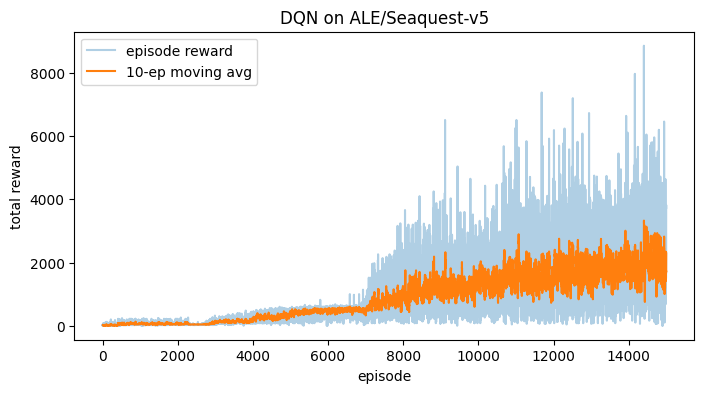

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on ALE/Seaquest-v5")
plt.legend()
if logger:
    plt.savefig(logger.dir / "reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Q visited-states


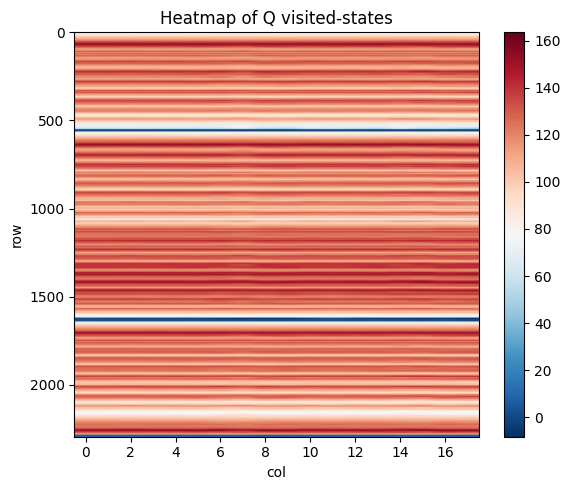

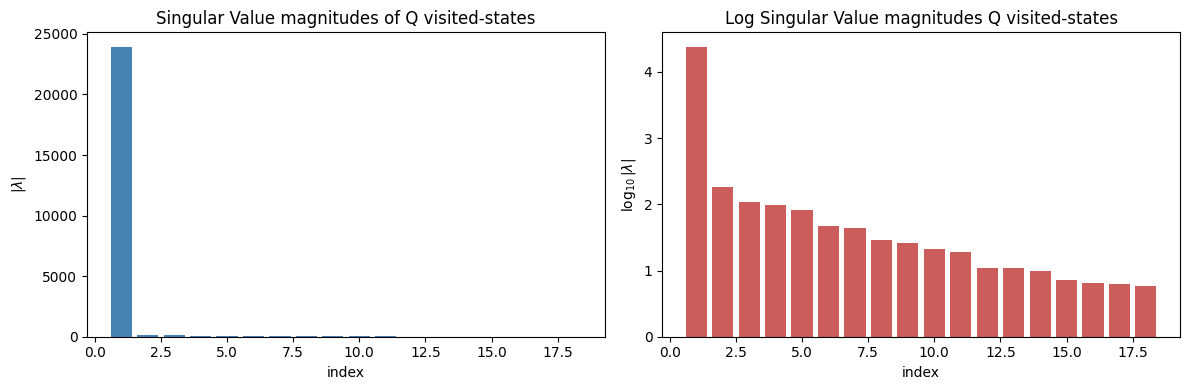

eff_rank: 1, stable_rank: 1.00, spikiness: 1.39, shape: (2296, 18), non-zero rows :2296, non-zero cols:18
top-r leverage spread: row min=4.246e-11 max=0.0007869 (uniform 0.0004355) | col min=0.05481 max=0.05609 (uniform 0.05556)
coherence score: row=1.807 col=1.01
Q latent-binned


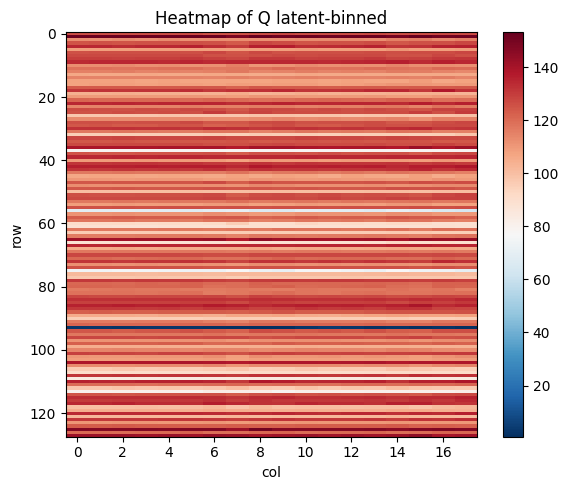

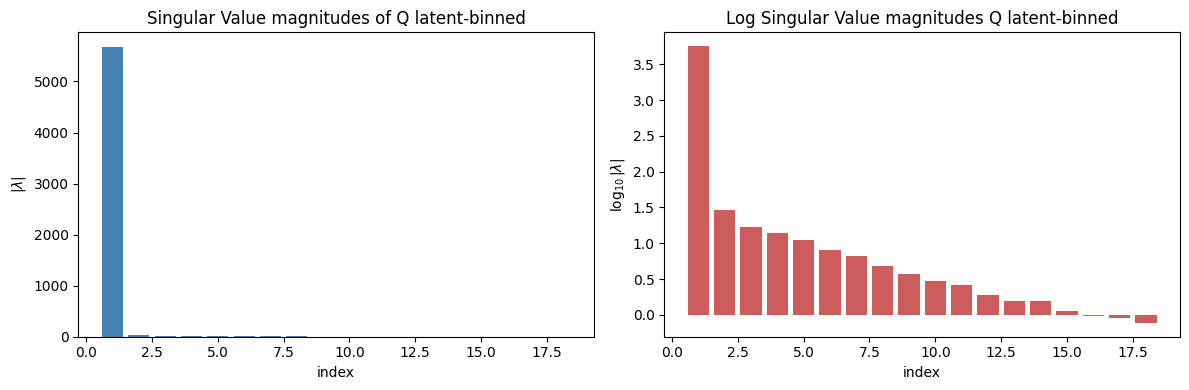

eff_rank: 1, stable_rank: 1.00, spikiness: 1.29, shape: (128, 18), non-zero rows :128, non-zero cols:18
top-r leverage spread: row min=2.459e-06 max=0.0128 (uniform 0.007812) | col min=0.05485 max=0.05596 (uniform 0.05556)
coherence score: row=1.638 col=1.007


In [9]:
# Post-training: run the generic per-matrix methods + the heavier post_methods
# (e.g. q_matrix_rollout) on the final policy, showing heatmap + spectrum for each.
# Hankel already ran every ep_freq during training (hankel_sweep.csv / figures).
methods = resolve_methods(cfg["analysis"].get("methods", []) + cfg["analysis"].get("post_methods", []))
for method, names in methods:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name, save_to=logger.figure_path(f"{name} heatmap") if logger else None)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name, save_to=logger.figure_path(name) if logger else None)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained agent and display it inline.

In [11]:
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = build_env(cfg, render_mode="rgb_array")
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=cfg["experiment"]["seed"])
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)

/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/dqn_seaquest/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


saved: videos/ep0-episode-0.mp4
